In [1]:
from resources.imports import *

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, RationalQuadratic as RQ, Matern
from sklearn.gaussian_process.kernels import WhiteKernel, ExpSineSquared as Exp
from sklearn.gaussian_process.kernels import Kernel
from sklearn.model_selection import GridSearchCV

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import GPRmodel

Hyperparameter Optimisation

Random Search
Grid-assisted Manual Search

Sequential Model-Based Optimization (SMBO)
- Gaussian Proccess (GP)
- Tree-structured Parzen Estimator (TPE)

In [3]:
DAT = DATA(load=True, model="GPR", format=1)

# Gaussian Process Regressor (GPR) Hyperparameters & Optimization

In [4]:
def GPR_HPopt(data, gpr, params, cv=5, verb=0):                  # TODO: Finish hopt
    grid_search = GridSearchCV(gpr, params, cv=cv, scoring=None, verbose=verb)
    return grid_search.fit(data[0], data[1])

In [22]:
Ckernel1 = C()*Exp(length_scale=24, periodicity=1)
Ckernel2 = C()*Exp(length_scale=24, periodicity=1)*RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5))
Ckernel3 = C()*Exp(length_scale=24, periodicity=1)*(RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5)) + Exp(length_scale=24, periodicity=1))

l, l_bounds = [0.1, 0.2, 0.5, 1, 2], (1e-5, 1e5)
a, a_bounds = 1, (1e-9, 1e9)
p, p_bounds = 1, (1e-9, 1e9)
kernel1 = RBF(length_scale=1, length_scale_bounds=l_bounds)  # C(length, (1e-3, 1e3)) * 
kernel2 = RQ(length_scale=l, alpha=a, length_scale_bounds=l_bounds, alpha_bounds=a_bounds)
kernel3 = Matern(length_scale=l, length_scale_bounds=l_bounds, nu=.5)
kernel4 = Exp(length_scale=l, periodicity=p, length_scale_bounds=l_bounds, periodicity_bounds=p_bounds)
kernel5 = WhiteKernel(noise_level=1e-3)

kernels = [RBF(i, l_bounds) for i in l]
alphas = [1e-20, 1e-10, 1e-5, 1e-3, 1e-2]
params = {"kernel": kernels, "alpha": alphas}

search_data = [DAT.train_in1, DAT.dx_out1[0]]
search = GPR_HPopt(search_data, GPR(), params) 

search.best_estimator_, search.best_params_["kernel"]

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

In [26]:
gpr1 = GPRmodel(K=kernel1, restarts=5, alpha=1e-5, data=[DAT.train_in1, DAT.dx_out1[0]])

In [34]:
gpr1.GPR.kernel_, len(gpr1.GPR.alpha_)

(RBF(length_scale=1), 357)

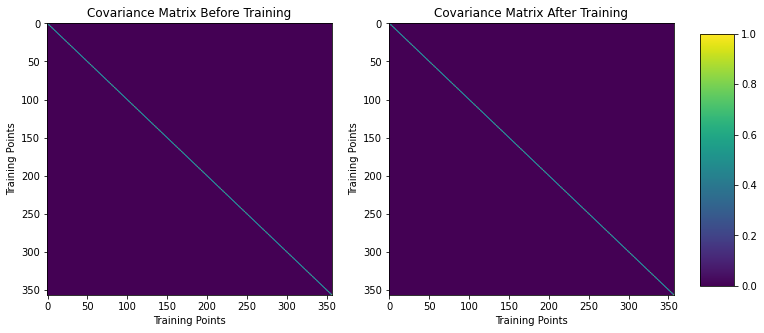

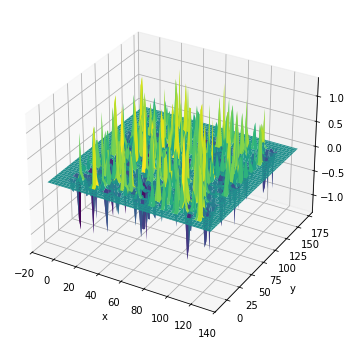

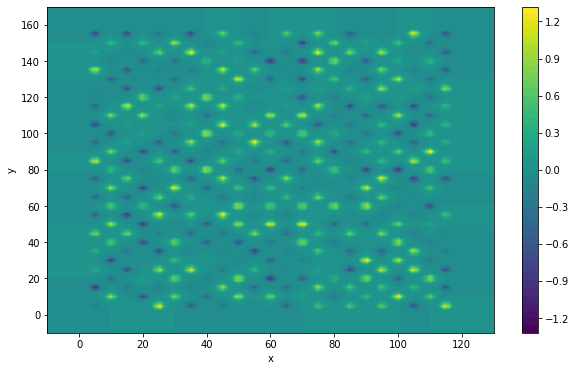

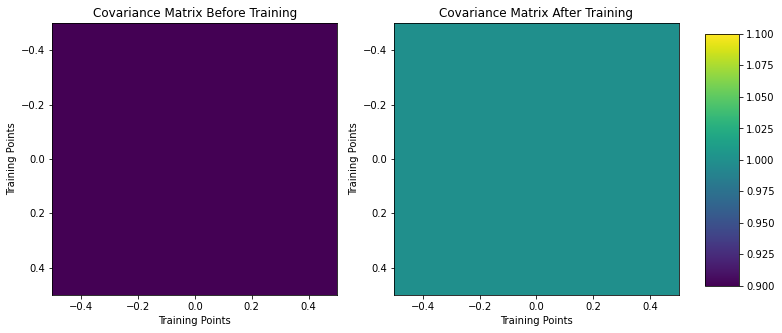

In [29]:
plot_Kmatrix(gpr1)
x_coords, y_coords, mean, std, cov = Fsurface(gpr=gpr1, density=100)
plot_Fsurface(x_coords, y_coords, mean, typ="both")
plot_Kmatrix(gpr1, x_coords)

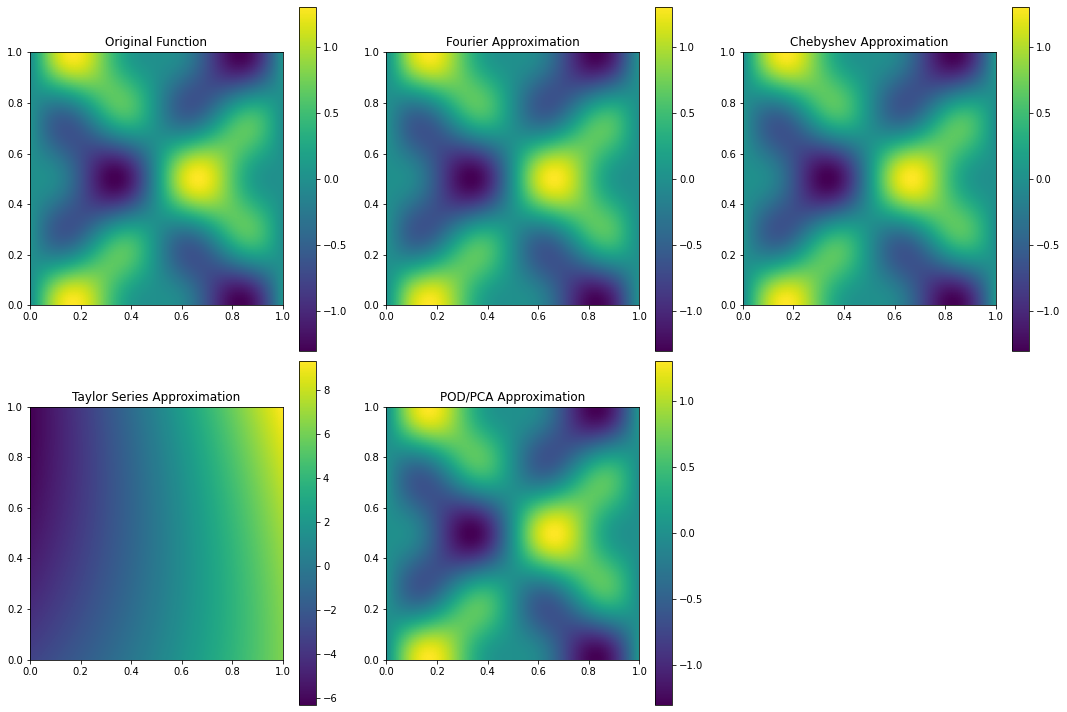

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander2d, chebval2d

# ---------------------------
# Define a sample 2D function
# ---------------------------
nx, ny = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

# Example function resembling a GP mean function output
def f(x, y):
    return np.sin(2*np.pi*x) * np.cos(2*np.pi*y) + 0.5*np.sin(4*np.pi*x) * np.cos(4*np.pi*y)

F = f(X, Y)

# ---------------------------
# 1. Fourier Series Approximation via FFT
# ---------------------------
# Compute the 2D FFT
F_fft = np.fft.fft2(F)
F_fft_shift = np.fft.fftshift(F_fft)

# Create a mask that keeps only the low-frequency components (a 10x10 block around the center)
keep = 10
mask = np.zeros_like(F_fft_shift, dtype=bool)
center_x, center_y = nx//2, ny//2
mask[center_x-keep:center_x+keep, center_y-keep:center_y+keep] = True

# Truncate the FFT coefficients and perform the inverse FFT
F_fft_truncated = np.zeros_like(F_fft_shift)
F_fft_truncated[mask] = F_fft_shift[mask]
F_fft_truncated_unshift = np.fft.ifftshift(F_fft_truncated)
F_fourier_approx = np.fft.ifft2(F_fft_truncated_unshift).real

# ---------------------------
# 2. Chebyshev Polynomial Approximation
# ---------------------------
# Chebyshev polynomials are defined on [-1, 1], so we remap x and y:
x_cheb = 2 * x - 1
y_cheb = 2 * y - 1
X_cheb, Y_cheb = np.meshgrid(x_cheb, y_cheb)

# Set degrees for the expansion in x and y
deg_x, deg_y = 10, 10

# Build the 2D Chebyshev Vandermonde matrix over the grid (flattened)
V = chebvander2d(X_cheb.ravel(), Y_cheb.ravel(), [deg_x, deg_y])

# Solve the least squares problem to obtain the Chebyshev coefficients
coeffs, _, _, _ = np.linalg.lstsq(V, F.ravel(), rcond=None)

# Reshape coefficients into a 2D array for evaluation and reconstruct the function
F_cheb_approx = chebval2d(X_cheb, Y_cheb, coeffs.reshape(deg_x+1, deg_y+1))

# ---------------------------
# 3. Taylor Series Expansion (Local, up to 2nd order)
# ---------------------------
# Choose the expansion point (e.g., the center of the domain)
x0, y0 = 0.5, 0.5
dx = x[1] - x[0]
dy = y[1] - y[0]

# Find indices near the expansion point
ix = np.argmin(np.abs(x - x0))
iy = np.argmin(np.abs(y - y0))

# Compute the function value and finite difference approximations for derivatives at (x0,y0)
f0 = F[iy, ix]
fx = (F[iy, ix+1] - F[iy, ix-1]) / (2*dx)
fy = (F[iy+1, ix] - F[iy-1, ix]) / (2*dy)
fxx = (F[iy, ix+1] - 2*F[iy, ix] + F[iy, ix-1]) / (dx**2)
fyy = (F[iy+1, ix] - 2*F[iy, ix] + F[iy-1, ix]) / (dy**2)
fxy = (F[iy+1, ix+1] - F[iy+1, ix-1] - F[iy-1, ix+1] + F[iy-1, ix-1]) / (4*dx*dy)

# Build the Taylor approximation for each grid point
F_taylor_approx = (f0 +
                   fx * (X - x0) +
                   fy * (Y - y0) +
                   0.5 * fxx * (X - x0)**2 +
                   0.5 * fyy * (Y - y0)**2 +
                   fxy * (X - x0) * (Y - y0))

# ---------------------------
# 4. Proper Orthogonal Decomposition (POD) / PCA via SVD
# ---------------------------
# For POD, we treat the 2D function F as a data matrix.
# First subtract the mean (here we compute the mean across rows)
F_mean = np.mean(F, axis=0)
F_centered = F - F_mean

# Compute the Singular Value Decomposition (SVD)
U, S, Vh = np.linalg.svd(F_centered, full_matrices=False)

# Choose a number of modes to retain; fewer modes mean a more compact approximation.
num_modes = 5
F_pod_approx = np.dot(U[:, :num_modes],
                      np.dot(np.diag(S[:num_modes]), Vh[:num_modes, :])) + F_mean

# ---------------------------
# Plotting All Approximations
# ---------------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Original function
im0 = axs[0, 0].imshow(F, extent=[0, 1, 0, 1], origin='lower')
axs[0, 0].set_title("Original Function")
fig.colorbar(im0, ax=axs[0, 0])

# Fourier approximation
im1 = axs[0, 1].imshow(F_fourier_approx, extent=[0, 1, 0, 1], origin='lower')
axs[0, 1].set_title("Fourier Approximation")
fig.colorbar(im1, ax=axs[0, 1])

# Chebyshev approximation
im2 = axs[0, 2].imshow(F_cheb_approx, extent=[0, 1, 0, 1], origin='lower')
axs[0, 2].set_title("Chebyshev Approximation")
fig.colorbar(im2, ax=axs[0, 2])

# Taylor series approximation
im3 = axs[1, 0].imshow(F_taylor_approx, extent=[0, 1, 0, 1], origin='lower')
axs[1, 0].set_title("Taylor Series Approximation")
fig.colorbar(im3, ax=axs[1, 0])

# POD/PCA approximation
im4 = axs[1, 1].imshow(F_pod_approx, extent=[0, 1, 0, 1], origin='lower')
axs[1, 1].set_title("POD/PCA Approximation")
fig.colorbar(im4, ax=axs[1, 1])

# Hide the unused subplot
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()


# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [10]:
gpr2 = GPRmodel(K=kernel1, restarts=5, alpha=0.3, data=[DAT.train_in[:500], DAT.train_out[:500]])
gpr2.fit(DAT.train_in, DAT.train_out)

y_mean, y_std = gpr2.predict(DAT.test_in, return_std=True)

In [ ]:
PLTidx = 1235

fig = plt.figure(num=1, figsize=(10,5))

plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.plot(DAT.perOUT[0], DAT.test_out[0]+DAT.perOUT[1], 'r-', label="Truth")
plt.plot(DAT.perOUT[0], y_mean[PLTidx]+DAT.perOUT[1], 'b-', label="Prediction")
plt.fill_between(DAT.perOUT[0], y_mean[PLTidx]+DAT.perOUT[1]-1.96*y_std[PLTidx], y_mean[PLTidx]+DAT.perOUT[1]+1.96*y_std[PLTidx], alpha=0.2)

plt.grid()
plt.legend()
